Importing the Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tlf
tlf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading the MNIST data from keras.datatsets

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


In [3]:
type(x_train)

numpy.ndarray

In [6]:
# shape of the numpy arrays 

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training data = 6,000 Images

Test data = 10,000 Images

Image Dimension --> 28 × 28

Grayscale Image --> 1 channel

In [8]:
# printing the 10th image 

print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [9]:
print(x_train[10].shape)

(28, 28)


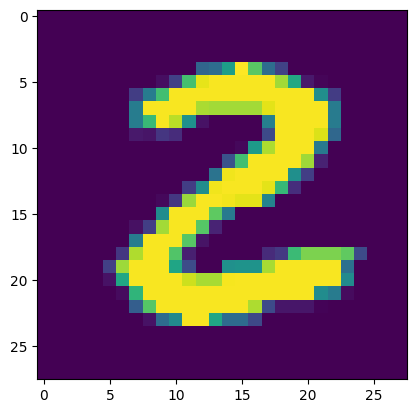

2


In [12]:
# displaying the image 

plt.imshow(x_train[25])
plt.show()

# print the corresponding label
print(y_train[25])

Image Labels

In [13]:
print(y_train.shape, y_test.shape)

(60000,) (10000,)


In [15]:
# unique values in y_train

print(np.unique(y_train))

# unique values in y_test

print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


We can use this labels as such or we can also apply One Hot Encoding

All the Images have the same dimensions in this dataset, If not, we have to resize all the images to a common dimension

In [16]:
# scaling the values 

x_train = x_train / 255
x_test = x_test / 255

In [17]:
# printing the 10th image 

print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the Neural Network

In [18]:
# setting up the layers of the Neural Network

model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(28,28)),
                          keras.layers.Dense(50, activation='relu'),
                          keras.layers.Dense(50, activation='relu'),
                          keras.layers.Dense(10, activation='sigmoid') # this is output layer
])

c:\Users\7odam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
# compiling the Neural Network 

model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
# training the Neural Network app 

model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9127 - loss: 0.3041
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9576 - loss: 0.1431
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9684 - loss: 0.1058
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9741 - loss: 0.0848
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9786 - loss: 0.0704
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9823 - loss: 0.0585
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9838 - loss: 0.0509
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9864 - loss: 0.0437
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9885 - loss: 0.0370
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9892 - loss: 0.0338


Training Data Accuracy = 98.9 %

Accuracy on Test Data:

In [21]:
loss, accuracy = model.evaluate(x_test, y_test)

print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9685 - loss: 0.1224
0.968500018119812


Test Data Accuracy = 96.8 %

In [22]:
print(x_test.shape)

(10000, 28, 28)


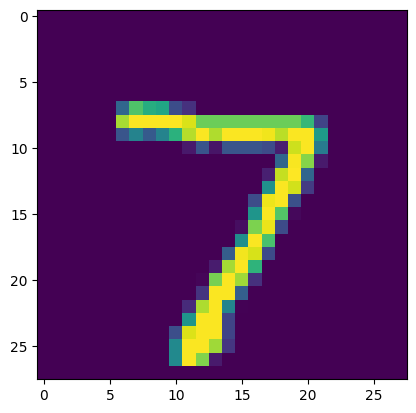

In [23]:
# first data point in x_test

plt.imshow(x_test[0])
plt.show()

In [24]:
print(y_test[0])

7


In [25]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [26]:
print(y_pred.shape)

(10000, 10)


In [27]:
print(y_pred[0])

[3.5267145e-05 4.4695762e-06 3.5259014e-01 9.9165171e-01 9.6753661e-07
 4.6178960e-04 3.9548347e-08 9.9999899e-01 2.7739465e-02 7.3242766e-01]


model.predict() gives the prediction probability of each class for that data point

In [28]:
# converting the prediction probabilites to class label

label_for_first_image = np.argmax(y_pred[0])

In [29]:
print(label_for_first_image)

7


In [30]:
# converting the prediction probabilites to class label for all test data points

y_pred_labels = [np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

y_test --> True Labels 

y_pred_labels --> Predicted Labels

Confusion Matrix

In [31]:
conf_matrix = confusion_matrix(y_test, y_pred_labels)

In [32]:
print(conf_matrix)

tf.Tensor(
[[ 949    0    2    0    6    3    0    2    2   16]
 [   1 1111    1    4    0    0    4    9    5    0]
 [   8    0  994    7    1    0    3   12    6    1]
 [   0    0    4  981    1    4    0    6    4   10]
 [   0    0    2    0  966    0    5    4    0    5]
 [   2    1    0   17    1  859    4    2    3    3]
 [   4    2    2    2    7    8  931    0    2    0]
 [   0    0    6    2    0    0    0 1005    1   14]
 [   1    0    4   14    6    7    2    4  932    4]
 [   1    2    0    5   28    2    0   10    4  957]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

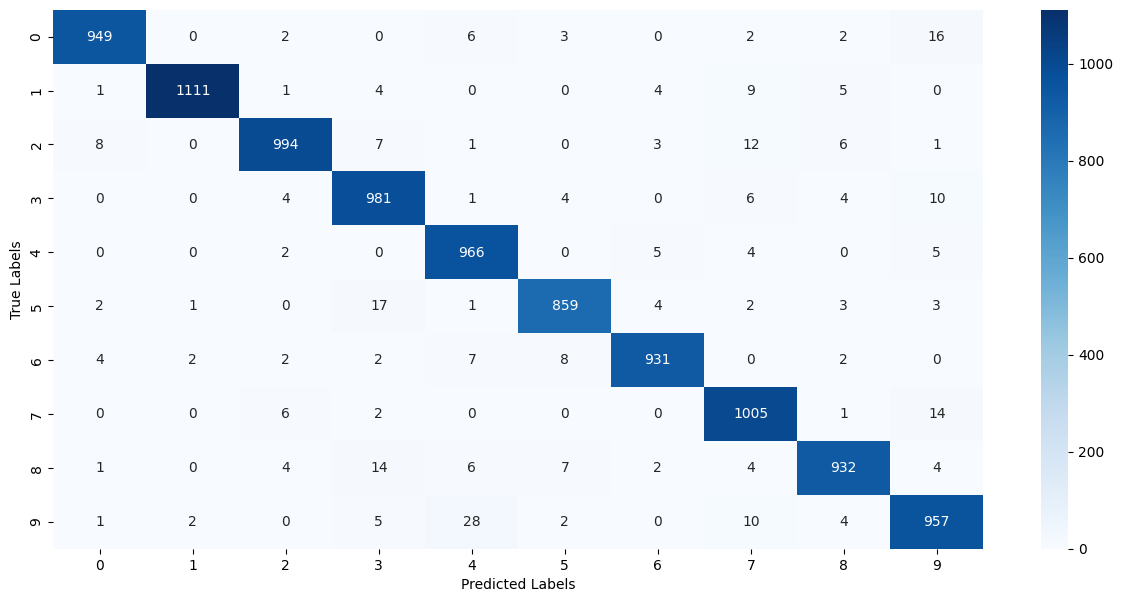

In [33]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

Building a Predictive System

In [35]:
input_image_path = 'MNIST_digit.png'

input_image = cv2.imread(input_image_path)

In [36]:
type(input_image)

numpy.ndarray

In [ ]:
print(input_image)

In [39]:
cv2.imshow('Gray Image', input_image)
cv2.waitKey(0)

-1

In [40]:
input_image.shape

(318, 318, 3)

In [41]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [42]:
grayscale.shape

(318, 318)

In [46]:
input_image_resized = cv2.resize(grayscale, (28, 28))

In [48]:
input_image_resized.shape

(28, 28)

In [49]:
cv2.imshow('Gray Image', input_image_resized)
cv2.waitKey(0)

-1

In [50]:
input_image_resized = input_image_resized / 255

In [52]:
image_reshaped = np.reshape(input_image_resized, [1, 28, 28])

In [53]:
input_prediction = model.predict(image_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [54]:
prediction_label = np.argmax(input_prediction)

In [55]:
print(prediction_label)

3


**Predicitive System**

In [56]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2.imshow('Gray Image', input_image)
cv2.waitKey(0)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resized = cv2.resize(grayscale, (28, 28))

input_image_resized = input_image_resized / 255

image_reshaped = np.reshape(input_image_resized, [1, 28, 28])

input_prediction = model.predict(image_reshaped)

prediction_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognised as ', prediction_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
The Handwritten Digit is recognised as  3
